# Trading Strategy

This notebook investigates whether the predictive signal identified in the
classification analysis can be translated into a simple trading strategy.

The strategy uses the balanced Logistic Regression classifier for AMZN at the
500 ms prediction horizon. The predictive performance of this model has already
been evaluated on the final held-out test day in the classification analysis.

In this notebook, the model is used to construct trading decisions. Any
strategy-specific parameters, such as confidence thresholds or trade-entry
rules, are determined without using the final test-day trading performance.
The resulting fixed strategy is then evaluated on March 20 as an out-of-sample
economic evaluation.

The strategy accounts for bid/ask execution and transaction costs. Performance
is summarized using measures such as the number of trades, hit rate, average
net return, and cumulative net return.

## Strategy Choice

The trading experiment uses the balanced Logistic Regression classifier for
AMZN at the 500 ms horizon.

This choice is based on the validation-stage classification results. Among
the three selected asset-horizon classification tasks, AMZN at 500 ms
achieved the highest validation balanced accuracy with the balanced Logistic
Regression model.

The trading strategy is therefore defined using this model before examining
the profitability of the final March 20 test day. Strategy-specific trading
parameters will be determined using the validation period and then frozen for
the final out-of-sample trading evaluation.

In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
ASSET = "AMZN"

TRAIN_DATES = [
    "2026-03-16",
    "2026-03-17",
    "2026-03-18",
]

VAL_DATE = "2026-03-19"
TEST_DATE = "2026-03-20"

TARGET = "target_500ms"

CLASSIFICATION_THRESHOLD = 2.340029718496282e-05

DATA_DIR = Path("../data/processed")

In [3]:
daily_data = {}

for date in TRAIN_DATES + [VAL_DATE, TEST_DATE]:

    path = DATA_DIR / f"{ASSET}_{date}.parquet"

    df = pd.read_parquet(path)

    daily_data[date] = df

    print(
        date,
        df.shape,
        df.index.min(),
        df.index.max()
    )

2026-03-16 (46800, 75) 2026-03-16 09:30:00-04:00 2026-03-16 15:59:59.500000-04:00
2026-03-17 (46800, 75) 2026-03-17 09:30:00-04:00 2026-03-17 15:59:59.500000-04:00
2026-03-18 (46800, 75) 2026-03-18 09:30:00-04:00 2026-03-18 15:59:59.500000-04:00
2026-03-19 (46800, 75) 2026-03-19 09:30:00-04:00 2026-03-19 15:59:59.500000-04:00
2026-03-20 (46800, 75) 2026-03-20 09:30:00-04:00 2026-03-20 15:59:59.500000-04:00


In [4]:
model_features = [
    # LOB state
    "spread",
    "imbalance_l1",
    "imbalance_l5",
    "bid_depth_5",
    "ask_depth_5",
    "microprice_deviation",

    # Order flow / activity
    "event_count",
    "execution_count",
    "normalized_book_flow",
    "execution_imbalance",

    # Past returns
    "return_500ms",
    "return_1s",
    "return_2s",
    "return_5s",
    "return_10s",

    # Volatility / recent activity
    "volatility_5s",
    "volatility_30s",
    "avg_events_5s",
    "avg_executions_5s",
]

print("Number of features:", len(model_features))

for date, df in daily_data.items():
    missing = [
        col for col in model_features
        if col not in df.columns
    ]

    print(date, "missing:", missing)

Number of features: 19
2026-03-16 missing: []
2026-03-17 missing: []
2026-03-18 missing: []
2026-03-19 missing: []
2026-03-20 missing: []


## Reconstruct the Frozen Classification Model

The trading strategy uses the same AMZN 500 ms classification target and the
same balanced Logistic Regression specification used in the classification
analysis.

The classification threshold is fixed from the training-period analysis.
The model is fitted using March 16–18 data only. March 19 is used to define
strategy-specific trading rules, while March 20 is reserved for the final
economic evaluation.

In [5]:
# Build chronological splits
train_df = pd.concat(
    [daily_data[d] for d in TRAIN_DATES],
    axis=0
).copy()

val_df = daily_data[VAL_DATE].copy()
test_df = daily_data[TEST_DATE].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (140400, 75)
Validation: (46800, 75)
Test: (46800, 75)


In [6]:
def make_classification_target(return_series, threshold):
    target = pd.Series(
        np.nan,
        index=return_series.index,
        dtype=float
    )

    valid = return_series.notna()

    target.loc[
        valid & (return_series < -threshold)
    ] = -1

    target.loc[
        valid &
        (return_series >= -threshold) &
        (return_series <= threshold)
    ] = 0

    target.loc[
        valid & (return_series > threshold)
    ] = 1

    return target

In [7]:
for df in [train_df, val_df, test_df]:
    df["classification_target"] = make_classification_target(
        df[TARGET],
        CLASSIFICATION_THRESHOLD
    )

In [8]:
for name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:

    counts = (
        df["classification_target"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    print("\n", name.upper())
    print(counts)


 TRAIN
classification_target
-1.0    27.868117
 0.0    44.562206
 1.0    27.569677
Name: proportion, dtype: float64

 VALIDATION
classification_target
-1.0    34.823394
 0.0    30.970747
 1.0    34.205859
Name: proportion, dtype: float64

 TEST
classification_target
-1.0    34.237911
 0.0    32.171628
 1.0    33.590461
Name: proportion, dtype: float64


In [9]:
train_mask = (
    train_df[model_features].notna().all(axis=1)
    & train_df["classification_target"].notna()
)

val_mask = (
    val_df[model_features].notna().all(axis=1)
    & val_df["classification_target"].notna()
)

test_mask = (
    test_df[model_features].notna().all(axis=1)
    & test_df["classification_target"].notna()
)

X_train = train_df.loc[train_mask, model_features]
y_train = train_df.loc[
    train_mask,
    "classification_target"
].astype(int)

X_val = val_df.loc[val_mask, model_features]
y_val = val_df.loc[
    val_mask,
    "classification_target"
].astype(int)

X_test = test_df.loc[test_mask, model_features]
y_test = test_df.loc[
    test_mask,
    "classification_target"
].astype(int)


trading_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

trading_model.fit(X_train, y_train)

print("Train rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Test rows:", len(X_test))

print(
    "Model classes:",
    trading_model.named_steps["classifier"].classes_
)

Train rows: 140217
Validation rows: 46739
Test rows: 46739
Model classes: [-1  0  1]


## Validation-Based Trading Rule

The classifier produces probabilities for DOWN, STATIONARY, and UP price
movements. Rather than trading every predicted class, the strategy uses the
validation day to determine a confidence threshold for directional trades.

A long signal is generated when the predicted probability of UP is sufficiently
high, while a short signal is generated when the predicted probability of DOWN
is sufficiently high. Otherwise, no position is taken.

All strategy-rule selection is performed using the validation day only. The
held-out test day is not used to choose the confidence threshold or any other
strategy parameter.

In [10]:
# Predicted class probabilities on validation data
val_proba = trading_model.predict_proba(X_val)

classes = trading_model.named_steps["classifier"].classes_
print("Class order:", classes)

class_to_idx = {
    cls: i for i, cls in enumerate(classes)
}

p_down = val_proba[:, class_to_idx[-1]]
p_stationary = val_proba[:, class_to_idx[0]]
p_up = val_proba[:, class_to_idx[1]]

print("Probability matrix shape:", val_proba.shape)

print("\nMean predicted probabilities:")
print("DOWN       :", p_down.mean())
print("STATIONARY :", p_stationary.mean())
print("UP         :", p_up.mean())

Class order: [-1  0  1]
Probability matrix shape: (46739, 3)

Mean predicted probabilities:
DOWN       : 0.3586962257579294
STATIONARY : 0.3223468751803467
UP         : 0.3189568990617239


In [11]:
directional_confidence = np.maximum(p_up, p_down)

print("Directional confidence quantiles:")

for q in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]:
    print(
        f"{q:.2f}: "
        f"{np.quantile(directional_confidence, q):.4f}"
    )

Directional confidence quantiles:
0.50: 0.3780
0.60: 0.3947
0.70: 0.4149
0.80: 0.4408
0.90: 0.4814
0.95: 0.5168
0.99: 0.5911


## Validation-Based Confidence Threshold Selection

The classifier's directional probabilities are relatively concentrated, so a
fixed probability cutoff such as 0.50 or 0.60 would be arbitrary. Candidate
thresholds are therefore constructed from quantiles of the directional
confidence distribution on the validation day.

For each threshold, a long signal is generated when the UP probability exceeds
both the DOWN probability and the threshold, and a short signal is generated
when the DOWN probability exceeds both the UP probability and the threshold.
Otherwise, the strategy remains flat.

Candidate thresholds are compared using March 19 only. March 20 remains
completely untouched during strategy design.

In [12]:
# Actual 500 ms future returns corresponding exactly to X_val
val_returns = val_df.loc[val_mask, TARGET].to_numpy()

candidate_quantiles = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]

threshold_results = []

for q in candidate_quantiles:

    threshold = np.quantile(directional_confidence, q)

    signals = np.zeros(len(val_returns), dtype=int)

    signals[
        (p_up > p_down) &
        (p_up >= threshold)
    ] = 1

    signals[
        (p_down > p_up) &
        (p_down >= threshold)
    ] = -1

    trade_mask = signals != 0
    n_trades = trade_mask.sum()

    strategy_returns = signals * val_returns

    if n_trades > 0:
        trade_accuracy = np.mean(
            np.sign(val_returns[trade_mask]) ==
            signals[trade_mask]
        )

        mean_trade_return = strategy_returns[trade_mask].mean()
        cumulative_gross_return = strategy_returns.sum()
    else:
        trade_accuracy = np.nan
        mean_trade_return = np.nan
        cumulative_gross_return = np.nan

    threshold_results.append({
        "quantile": q,
        "threshold": threshold,
        "n_signals": n_trades,
        "signal_rate": n_trades / len(signals),
        "directional_accuracy": trade_accuracy,
        "mean_gross_return_per_signal": mean_trade_return,
        "cumulative_gross_return": cumulative_gross_return,
    })

threshold_results_df = pd.DataFrame(threshold_results)

display(threshold_results_df)

,quantile,threshold,n_signals,signal_rate,directional_accuracy,mean_gross_return_per_signal,cumulative_gross_return
0,0.50,0.377960,23370,0.500011,0.434489,0.000008,0.187616
1,0.60,0.394702,18696,0.400009,0.444106,0.000009,0.169469
2,0.70,0.414858,14022,0.300006,0.455427,0.000010,0.138770
3,0.80,0.440842,9348,0.200004,0.463415,0.000011,0.099187
4,0.90,0.481393,4674,0.100002,0.482884,0.000014,0.066961
5,0.95,0.516803,2337,0.050001,0.489089,0.000013,0.031039
6,0.99,0.591136,468,0.010013,0.517094,0.000019,0.009057


## Transaction Costs and Executable Positions

The previous analysis treats each qualifying prediction as a signal rather than
as an independent trade. Because predictions are generated every 500 ms,
consecutive signals can correspond to the same desired position.

The strategy therefore converts signals into positions in {-1, 0, +1} and
charges transaction costs when the position changes. Turnover is measured as
the absolute change in position: entering or exiting a position has turnover
1, while reversing directly from long to short or short to long has turnover 2.

Candidate confidence thresholds are evaluated on the validation day after
transaction costs. The final threshold is fixed before evaluating the held-out
test day.

In [13]:
cost_bps_list = [0.0, 0.1, 0.5, 1.0]

execution_results = []

for q in candidate_quantiles:

    threshold = np.quantile(directional_confidence, q)

    position = np.zeros(len(val_returns), dtype=int)

    position[
        (p_up > p_down) &
        (p_up >= threshold)
    ] = 1

    position[
        (p_down > p_up) &
        (p_down >= threshold)
    ] = -1

    # Gross P&L from the desired position
    gross_returns = position * val_returns

    # Position changes determine turnover.
    # 0 -> 1  : turnover = 1
    # 1 -> 0  : turnover = 1
    # 1 -> -1 : turnover = 2
    previous_position = np.r_[0, position[:-1]]
    turnover = np.abs(position - previous_position)

    for cost_bps in cost_bps_list:

        cost_per_unit_turnover = cost_bps * 1e-4

        transaction_costs = (
            turnover * cost_per_unit_turnover
        )

        net_returns = gross_returns - transaction_costs

        execution_results.append({
            "quantile": q,
            "threshold": threshold,
            "cost_bps": cost_bps,
            "active_rate": np.mean(position != 0),
            "position_changes": np.sum(turnover > 0),
            "total_turnover": turnover.sum(),
            "gross_return": gross_returns.sum(),
            "transaction_cost": transaction_costs.sum(),
            "net_return": net_returns.sum(),
        })

execution_results_df = pd.DataFrame(execution_results)

display(
    execution_results_df.round(6)
)

,quantile,threshold,cost_bps,active_rate,position_changes,total_turnover,gross_return,transaction_cost,net_return
0,0.50,0.377960,0.0,0.500011,17557,23511,0.187616,0.00000,0.187616
1,0.50,0.377960,0.1,0.500011,17557,23511,0.187616,0.23511,-0.047494
2,0.50,0.377960,0.5,0.500011,17557,23511,0.187616,1.17555,-0.987934
3,0.50,0.377960,1.0,0.500011,17557,23511,0.187616,2.35110,-2.163484
4,0.60,0.394702,0.0,0.400009,15413,19851,0.169469,0.00000,0.169469
5,0.60,0.394702,0.1,0.400009,15413,19851,0.169469,0.19851,-0.029041
6,0.60,0.394702,0.5,0.400009,15413,19851,0.169469,0.99255,-0.823081
7,0.60,0.394702,1.0,0.400009,15413,19851,0.169469,1.98510,-1.815631
8,0.70,0.414858,0.0,0.300006,12764,15787,0.138770,0.00000,0.138770
9,0.70,0.414858,0.1,0.300006,12764,15787,0.138770,0.15787,-0.019100


## One-Period Trading Strategy

Because the classification model predicts the return over the next 500 ms,
each qualifying prediction is interpreted as a one-period trading opportunity.

A position is opened at the current observation and held for the 500 ms
forecast horizon. The position is then closed before the next trading
decision. This avoids treating overlapping model signals as continuously
held positions and provides a direct correspondence between the prediction
target and the economic return being evaluated.

Each completed trade therefore incurs a round-trip transaction cost.
Confidence thresholds and trading-rule parameters continue to be evaluated
using the validation day only.

Position sizing is discrete: observations below the confidence threshold receive
position size zero, while qualifying directional signals are traded with unit
long (+1) or short (-1) exposure.

In [14]:
round_trip_cost_bps_list = [0.0, 0.1, 0.2, 0.5, 1.0]

trade_results = []

for q in candidate_quantiles:

    threshold = np.quantile(directional_confidence, q)

    signals = np.zeros(len(val_returns), dtype=int)

    signals[
        (p_up > p_down) &
        (p_up >= threshold)
    ] = 1

    signals[
        (p_down > p_up) &
        (p_down >= threshold)
    ] = -1

    trade_mask = signals != 0

    gross_trade_returns = (
        signals[trade_mask] *
        val_returns[trade_mask]
    )

    n_trades = trade_mask.sum()

    for round_trip_cost_bps in round_trip_cost_bps_list:

        cost = round_trip_cost_bps * 1e-4

        net_trade_returns = (
            gross_trade_returns - cost
        )

        trade_results.append({
            "quantile": q,
            "threshold": threshold,
            "round_trip_cost_bps": round_trip_cost_bps,
            "n_trades": n_trades,
            "trade_rate": n_trades / len(signals),
            "mean_gross_return": (
                gross_trade_returns.mean()
                if n_trades else np.nan
            ),
            "mean_net_return": (
                net_trade_returns.mean()
                if n_trades else np.nan
            ),
            "cumulative_gross_return":
                gross_trade_returns.sum(),
            "cumulative_net_return":
                net_trade_returns.sum(),
        })

trade_results_df = pd.DataFrame(trade_results)

display(trade_results_df.round(7))

,quantile,threshold,round_trip_cost_bps,n_trades,trade_rate,mean_gross_return,mean_net_return,cumulative_gross_return,cumulative_net_return
0,0.50,0.377960,0.0,23370,0.500011,0.000008,8.000000e-06,0.187616,0.187616
1,0.50,0.377960,0.1,23370,0.500011,0.000008,-2.000000e-06,0.187616,-0.046084
2,0.50,0.377960,0.2,23370,0.500011,0.000008,-1.200000e-05,0.187616,-0.279784
3,0.50,0.377960,0.5,23370,0.500011,0.000008,-4.200000e-05,0.187616,-0.980884
4,0.50,0.377960,1.0,23370,0.500011,0.000008,-9.200000e-05,0.187616,-2.149384
5,0.60,0.394702,0.0,18696,0.400009,0.000009,9.100000e-06,0.169469,0.169469
6,0.60,0.394702,0.1,18696,0.400009,0.000009,-9.000000e-07,0.169469,-0.017491
7,0.60,0.394702,0.2,18696,0.400009,0.000009,-1.090000e-05,0.169469,-0.204451
8,0.60,0.394702,0.5,18696,0.400009,0.000009,-4.090000e-05,0.169469,-0.765331
9,0.60,0.394702,1.0,18696,0.400009,0.000009,-9.090000e-05,0.169469,-1.700131


### Stress Test: Transaction-Cost Sensitivity

To assess whether the apparent trading signal is robust to market frictions,
the validation strategy was evaluated across several round-trip transaction-cost
assumptions.

The results show that profitability is highly sensitive to even small trading
costs. Although the strategy exhibits a weak positive gross return before costs,
the edge rapidly deteriorates as transaction costs increase. Higher-confidence
thresholds reduce the number of trades and improve the average gross return per
trade, but the remaining predictive edge is still small relative to plausible
high-frequency trading costs.

This sensitivity analysis therefore indicates that statistical directional
predictability does not automatically translate into an economically robust
trading strategy.

### Validation-Based Trading Rule Selection

The trading rule was selected using the validation day only. Directional
predictions were filtered according to the model's confidence, and candidate
thresholds corresponding to validation confidence quantiles from 0.50 to
0.99 were evaluated.

Higher confidence thresholds generally produced higher mean gross returns
per trade, but at the cost of substantially fewer trading opportunities.
After including a round-trip transaction cost of 0.1 basis points, the
90th-percentile confidence threshold provided the highest cumulative net
return among the candidate thresholds. This threshold corresponds to a
directional confidence of approximately 0.4814 and generates signals for
approximately 10% of validation observations.

The final trading rule is therefore fixed at a confidence threshold of
0.481393. This numerical threshold, rather than the 90th percentile of the
test-day confidence distribution, will be applied unchanged to the held-out
test day. No trading-rule parameter will be selected or adjusted using test
performance.

In [15]:
# Freeze the trading-rule parameters selected on validation data
FINAL_CONFIDENCE_THRESHOLD = 0.481393
FINAL_ROUND_TRIP_COST_BPS = 0.1


## Spread-Aware Executable Strategy

The earlier analysis evaluated the predictive signal using future mid-price
returns. The final trading backtest instead uses executable bid and ask prices.

For a long trade, the strategy enters at the current best ask and exits
500 ms later at the best bid. For a short trade, it enters at the current
best bid and covers 500 ms later at the best ask. This explicitly incorporates
the bid-ask spread into each round trip.

An additional fixed transaction cost of 0.1 basis points per completed trade
is applied on top of the quoted-spread execution cost. The confidence threshold
remains frozen at 0.481393, as selected using validation data only.

In [16]:
def executable_trade_returns(df, mask, signals):
    trade_df = df.loc[mask].copy()

    ask_now = trade_df["sell1"].to_numpy()
    bid_now = trade_df["buy1"].to_numpy()

    ask_next = trade_df["sell1"].shift(-1).to_numpy()
    bid_next = trade_df["buy1"].shift(-1).to_numpy()

    executable_returns = np.full(len(signals), np.nan)

    long_mask = signals == 1
    executable_returns[long_mask] = np.log(
        bid_next[long_mask] / ask_now[long_mask]
    )

    short_mask = signals == -1
    executable_returns[short_mask] = np.log(
        bid_now[short_mask] / ask_next[short_mask]
    )

    return executable_returns

In [17]:
val_signals_final = np.zeros(len(val_returns), dtype=int)

val_signals_final[
    (p_up > p_down) &
    (p_up >= FINAL_CONFIDENCE_THRESHOLD)
] = 1

val_signals_final[
    (p_down > p_up) &
    (p_down >= FINAL_CONFIDENCE_THRESHOLD)
] = -1

val_exec_returns = executable_trade_returns(
    val_df,
    val_mask,
    val_signals_final
)

val_trade_mask = (
    (val_signals_final != 0) &
    np.isfinite(val_exec_returns)
)

cost = FINAL_ROUND_TRIP_COST_BPS * 1e-4

val_gross_exec = val_exec_returns[val_trade_mask]
val_net_exec = val_gross_exec - cost

validation_execution_summary = pd.Series({
    "n_trades": val_trade_mask.sum(),
    "mean_gross_return": val_gross_exec.mean(),
    "mean_net_return": val_net_exec.mean(),
    "cumulative_gross_return": val_gross_exec.sum(),
    "cumulative_net_return": val_net_exec.sum(),
})

display(validation_execution_summary)

n_trades                   4672.000000
mean_gross_return            -0.000130
mean_net_return              -0.000140
cumulative_gross_return      -0.609573
cumulative_net_return        -0.656293
dtype: float64

## Final Out-of-Sample Trading Evaluation

The trading-rule parameters were selected using the March 19 validation day
and are now fixed. The held-out March 20 test day is used only for the final
economic evaluation.

The final evaluation uses executable bid and ask prices rather than future
mid-price returns. Long positions enter at the current best ask and exit at
the future best bid, while short positions enter at the current best bid and
exit at the future best ask. Therefore, the quoted bid-ask spread is explicitly
incorporated into realized returns.

The confidence threshold is fixed at 0.481393. An additional round-trip
transaction cost of 0.1 basis points is applied on top of the quoted-spread
execution cost. No parameter is adjusted using test-day performance.

In [18]:
# Test-set probabilities
test_proba = trading_model.predict_proba(X_test)

classes = trading_model.named_steps["classifier"].classes_
class_to_idx = {cls: i for i, cls in enumerate(classes)}

p_down_test = test_proba[:, class_to_idx[-1]]
p_up_test = test_proba[:, class_to_idx[1]]

# Frozen trading rule
test_signals = np.zeros(len(test_proba), dtype=int)

test_signals[
    (p_up_test > p_down_test) &
    (p_up_test >= FINAL_CONFIDENCE_THRESHOLD)
] = 1

test_signals[
    (p_down_test > p_up_test) &
    (p_down_test >= FINAL_CONFIDENCE_THRESHOLD)
] = -1

# Spread-aware executable returns:
# Long  = buy at current ask, sell at future bid
# Short = sell at current bid, buy at future ask
test_exec_returns = executable_trade_returns(
    test_df,
    test_mask,
    test_signals
)

test_trade_mask = (
    (test_signals != 0) &
    np.isfinite(test_exec_returns)
)

# Additional fixed round-trip cost
cost = FINAL_ROUND_TRIP_COST_BPS * 1e-4

test_gross_exec = test_exec_returns[test_trade_mask]
test_net_exec = test_gross_exec - cost

test_execution_summary = pd.Series({
    "n_trades": test_trade_mask.sum(),
    "trade_rate": test_trade_mask.mean(),
    "mean_gross_return": test_gross_exec.mean(),
    "mean_net_return": test_net_exec.mean(),
    "cumulative_gross_return": test_gross_exec.sum(),
    "cumulative_net_return": test_net_exec.sum(),
})

display(test_execution_summary)

n_trades                   2503.000000
trade_rate                    0.053553
mean_gross_return            -0.000130
mean_net_return              -0.000140
cumulative_gross_return      -0.324282
cumulative_net_return        -0.349312
dtype: float64

In [19]:
spread_aware_hit_rate = np.mean(test_net_exec > 0)

print(
    "Spread-aware profitable-trade hit rate:",
    round(spread_aware_hit_rate, 6)
)

Spread-aware profitable-trade hit rate: 0.077107


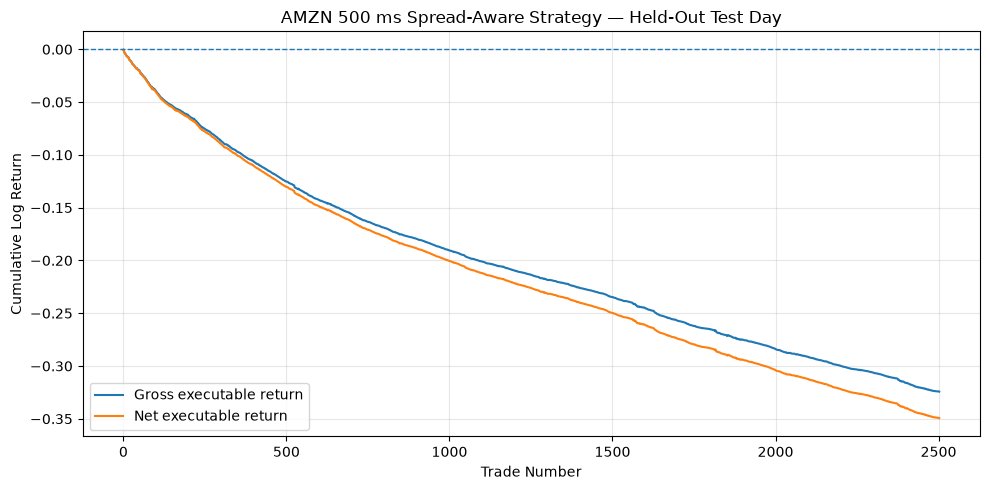

In [20]:
import matplotlib.pyplot as plt

cumulative_gross_exec = np.cumsum(test_gross_exec)
cumulative_net_exec = np.cumsum(test_net_exec)

plt.figure(figsize=(10, 5))

plt.plot(
    cumulative_gross_exec,
    label="Gross executable return"
)

plt.plot(
    cumulative_net_exec,
    label="Net executable return"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Trade Number")
plt.ylabel("Cumulative Log Return")

plt.title(
    "AMZN 500 ms Spread-Aware Strategy — Held-Out Test Day"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Signal-versus-Spread Decomposition

The final executable strategy is decomposed to distinguish the predictive
mid-price signal from the cost of crossing the bid-ask spread.

For each executed trade, the directional mid-price return measures how much
the future mid-price moves in the model's predicted direction. The executable
gross return then replaces mid-price execution with the current and future
best bid/ask prices. The difference between these quantities represents the
effective spread burden associated with immediate taker execution.

This is a diagnostic decomposition of the already-fixed held-out strategy;
no model, threshold, or trading parameter is re-selected using test data.

In [22]:
# ============================================================
# Signal-versus-spread decomposition
# Final held-out test day only — diagnostic, no re-selection
# ============================================================

# Rows used by the final trading model
trade_eval_df = test_df.loc[test_mask].copy()

# Current executable quotes
current_bid = trade_eval_df["buy1"].to_numpy(dtype=float)
current_ask = trade_eval_df["sell1"].to_numpy(dtype=float)

# Future executable quotes one 500 ms grid step later.
# Shift on the FULL test day first, then apply the same mask so the
# future quote corresponds to t + 500 ms rather than the next valid row.
future_bid = (
    test_df["buy1"]
    .shift(-1)
    .loc[test_mask]
    .to_numpy(dtype=float)
)

future_ask = (
    test_df["sell1"]
    .shift(-1)
    .loc[test_mask]
    .to_numpy(dtype=float)
)

# Original 500 ms future mid-price return
mid_returns = (
    test_df.loc[test_mask, TARGET]
    .to_numpy(dtype=float)
)
# Frozen test-day trading signals: -1 short, 0 no trade, +1 long
signals = np.asarray(test_signals, dtype=int)

active = signals != 0

# Directional return if both entry and exit were evaluated at mid-price
directional_mid_return = signals * mid_returns

# Gross executable return using bid/ask prices
executable_gross_return = np.full(
    len(signals),
    np.nan,
    dtype=float
)

long_mask = signals == 1
short_mask = signals == -1

# Long: buy at current ask, liquidate at future bid
executable_gross_return[long_mask] = np.log(
    future_bid[long_mask] / current_ask[long_mask]
)

# Short: sell at current bid, cover at future ask
executable_gross_return[short_mask] = np.log(
    current_bid[short_mask] / future_ask[short_mask]
)

# Restrict to valid executed trades
valid_trade = (
    active
    & np.isfinite(directional_mid_return)
    & np.isfinite(executable_gross_return)
)

mid_trade_returns = directional_mid_return[valid_trade]
exec_trade_returns = executable_gross_return[valid_trade]

# Spread burden = mid-price opportunity minus executable return
spread_drag = mid_trade_returns - exec_trade_returns

# Additional fixed round-trip transaction cost already assumed
fixed_cost_bps = 0.1
fixed_cost_return = fixed_cost_bps * 1e-4

net_trade_returns = (
    exec_trade_returns
    - fixed_cost_return
)

decomposition = pd.Series({
    "n_trades": valid_trade.sum(),

    "mean_directional_mid_return_bps":
        mid_trade_returns.mean() * 1e4,

    "mean_spread_drag_bps":
        spread_drag.mean() * 1e4,

    "mean_executable_gross_return_bps":
        exec_trade_returns.mean() * 1e4,

    "additional_round_trip_cost_bps":
        fixed_cost_bps,

    "mean_executable_net_return_bps":
        net_trade_returns.mean() * 1e4,
})

display(decomposition)

n_trades                            2503.000000
mean_directional_mid_return_bps        0.134435
mean_spread_drag_bps                   1.430008
mean_executable_gross_return_bps      -1.295573
additional_round_trip_cost_bps         0.100000
mean_executable_net_return_bps        -1.395573
dtype: float64

### Interpretation of the Signal-versus-Spread Decomposition

The held-out strategy exhibits a small positive directional mid-price signal,
with an average predicted-direction return of approximately **+0.134 bp per
trade**. However, the effective cost of crossing the bid-ask spread is much
larger, averaging approximately **1.430 bp per trade**.

Consequently, the average executable gross return becomes approximately
**-1.296 bp per trade**, even before applying the additional fixed transaction
cost. After the assumed **0.1 bp round-trip cost**, the average net return is
approximately **-1.396 bp per trade**.

This decomposition shows that the strategy's economic failure is primarily
driven by the gap between the weak short-horizon predictive signal and the
bid-ask spread, rather than by the additional fixed transaction-cost
assumption. The classifier contains some directional information at the
mid-price level, but the magnitude of that signal is insufficient to support
immediate taker execution at a 500 ms horizon.

## Execution-Latency Stress Test

The trading rule, confidence threshold, and model are kept fixed. To test
whether the short-horizon signal survives realistic execution delay, the same
signals are evaluated assuming execution occurs 0 ms, 500 ms, or 1 s after
signal generation.

For each delayed entry, the position is held for the same 500 ms holding
period. Thus, this experiment measures whether the predictive information
persists long enough to remain useful after an operational delay.

No parameter is re-selected using the held-out test day; this is a diagnostic
stress test of the already-fixed strategy.

In [23]:
# ============================================================
# Execution-latency stress test
# Frozen model, frozen threshold, frozen signals
# Holding period remains 500 ms
# ============================================================

latency_results = []

# 500 ms grid:
# 0 steps = 0 ms delay
# 1 step  = 500 ms delay
# 2 steps = 1 s delay
latency_steps = {
    "0 ms": 0,
    "500 ms": 1,
    "1 s": 2,
}

signals = np.asarray(test_signals, dtype=int)

for latency_label, latency in latency_steps.items():

    # Entry occurs latency steps after signal generation
    entry_bid = (
        test_df["buy1"]
        .shift(-latency)
        .loc[test_mask]
        .to_numpy(dtype=float)
    )

    entry_ask = (
        test_df["sell1"]
        .shift(-latency)
        .loc[test_mask]
        .to_numpy(dtype=float)
    )

    # Exit 500 ms after delayed entry
    exit_bid = (
        test_df["buy1"]
        .shift(-(latency + 1))
        .loc[test_mask]
        .to_numpy(dtype=float)
    )

    exit_ask = (
        test_df["sell1"]
        .shift(-(latency + 1))
        .loc[test_mask]
        .to_numpy(dtype=float)
    )

    gross_returns = np.full(
        len(signals),
        np.nan,
        dtype=float
    )

    long_mask = signals == 1
    short_mask = signals == -1

    # Long:
    # buy at delayed ask, sell 500 ms later at bid
    gross_returns[long_mask] = np.log(
        exit_bid[long_mask]
        / entry_ask[long_mask]
    )

    # Short:
    # sell at delayed bid, buy back 500 ms later at ask
    gross_returns[short_mask] = np.log(
        entry_bid[short_mask]
        / exit_ask[short_mask]
    )

    valid_trade = (
        (signals != 0)
        & np.isfinite(gross_returns)
    )

    gross_trade_returns = gross_returns[valid_trade]

    # Same frozen 0.1 bp round-trip cost
    net_trade_returns = (
        gross_trade_returns
        - 0.1e-4
    )

    latency_results.append({
        "execution_delay": latency_label,
        "n_trades": valid_trade.sum(),
        "mean_gross_return_bps":
            gross_trade_returns.mean() * 1e4,
        "mean_net_return_bps":
            net_trade_returns.mean() * 1e4,
        "gross_hit_rate":
            np.mean(gross_trade_returns > 0),
        "cumulative_gross_return":
            gross_trade_returns.sum(),
        "cumulative_net_return":
            net_trade_returns.sum(),
    })

latency_results_df = pd.DataFrame(
    latency_results
)

display(latency_results_df)

,execution_delay,n_trades,mean_gross_return_bps,mean_net_return_bps,gross_hit_rate,cumulative_gross_return,cumulative_net_return
0,0 ms,2503,-1.295573,-1.395573,0.077107,-0.324282,-0.349312
1,500 ms,2503,-1.506486,-1.606486,0.055134,-0.377073,-0.402103
2,1 s,2502,-1.477155,-1.577155,0.052358,-0.369584,-0.394604


### Latency Stress-Test Interpretation

Execution delay further weakens the already-unprofitable spread-aware strategy.

With immediate execution, the mean executable gross return is approximately
**-1.296 bp per trade**, with a gross profitable-trade rate of **7.71%**.
Introducing a **500 ms delay** reduces mean gross return to approximately
**-1.506 bp per trade** and the hit rate to **5.51%**. With a **1 s delay**,
mean gross return remains strongly negative at approximately **-1.477 bp per
trade**, while the hit rate falls further to **5.24%**.

The degradation is not perfectly monotonic across the two delay levels, but
both delayed cases are worse than immediate execution. This indicates that the
short-horizon predictive signal is fragile to operational latency and does not
persist strongly enough to overcome executable trading frictions.

Together with the signal-versus-spread decomposition, the stress test suggests
that the main economic limitation is a combination of a weak short-horizon
signal, a much larger bid-ask spread burden, and rapid signal decay.

## Final Trading Strategy Conclusion

The final trading strategy uses the AMZN 500 ms balanced Logistic Regression
classifier. The confidence threshold was selected using the March 19 validation
day and then fixed before evaluation on the held-out March 20 test day.
Qualifying directional predictions receive unit long (+1) or short (-1)
exposure, while lower-confidence observations remain untraded. The holding
period is one 500 ms interval.

Under the frozen trading rule, the final held-out evaluation produces
approximately **2,503 trades**, corresponding to a trade rate of about
**5.36%**.

A mid-price view alone suggests that the classifier contains a small amount of
directional information. The signal-versus-spread decomposition shows an
average directional mid-price return of approximately **+0.134 bp per trade**.
However, the effective burden from crossing the bid-ask spread is approximately
**1.430 bp per trade**, which is more than ten times larger than the predictive
mid-price signal.

As a result, the mean executable gross return is approximately
**-1.296 bp per trade**. After the additional assumed **0.1 bp round-trip
transaction cost**, the mean executable net return falls to approximately
**-1.396 bp per trade**, with cumulative gross and net returns of approximately
**-0.324** and **-0.349**, respectively. Only about **7.71%** of the executable
trades are profitable.

The latency stress test reinforces this conclusion. Keeping the model,
threshold, position rule, and 500 ms holding period fixed, delaying execution
by 500 ms lowers the mean executable gross return to approximately
**-1.506 bp per trade**, while a 1 s delay produces approximately
**-1.477 bp per trade**. The profitable-trade rate also decreases to roughly
**5.51%** and **5.24%**, respectively.

Therefore, the negative economic result is not primarily caused by the assumed
0.1 bp fixed transaction cost. The main limitation is that the model's
short-horizon directional signal is much smaller than the bid-ask spread and
is additionally fragile to execution latency. The strategy therefore provides
evidence of weak statistical predictability, but not of an economically
executable trading edge under immediate taker execution.